# Harmonisation Evaluation Metrics

In this section, we will explore several approaches for evaluating harmonisation performance in longitudinal and multi-site imaging data.

---

## Reliability-Based Metrics

We first examine:

- **Within-Subject Variability**
- **Subject Order Consistency**

These metrics are particularly useful for:

- test-retest datasets,
- traveling-subject datasets,
- or scenarios where little or no biological change is expected over time.

The goal is to evaluate the reliability and consistency of measurements across scanners, sites, or repeated acquisitions.

### Why this matters

If no true biological change is expected, large differences between repeated scans may indicate:

- scanner/site effects,
- measurement instability,
- or technical variability.

Reliable measurements are especially important in clinical and longitudinal studies where subtle biological effects are being investigated.

---

## Batch-Effect Evaluation

We then evaluate:

- **Additive Batch Effects**
- **Multiplicative Batch Effects**

These analyses can be applied to both:

- test-retest datasets,
- and true longitudinal datasets with expected biological change.

### What these tests assess

- **Additive effects** evaluate whether scanners/sites introduce systematic shifts in mean values.
- **Multiplicative effects** evaluate whether scanners/sites introduce scaling/variance differences.

These effects are important because many harmonisation methods, including ComBat-like approaches, are specifically designed to estimate and remove additive and multiplicative batch effects while preserving biological signal.

Together, these metrics provide complementary information about:
- measurement reliability,
- preservation of biological structure,
- and residual scanner/site-related bias after harmonisation.

## Simulated Harmonisation Dataset Parameters

The simulated dataset is generated using:

```python
df = simulate_harmonisation_data(
    n_subjects=n_subjects,
    n_timepoints=n_timepoints,
    n_features=n_features,
    seed=1,
    subject_mean=2000,
    subject_sd=80,
    noise_sd=20,
    scale=100
)
```

### Parameter Descriptions

| Parameter      | Description                                              |
| -------------- | -------------------------------------------------------- |
| `n_subjects`   | Number of simulated subjects/participants                |
| `n_timepoints` | Number of repeated longitudinal measurements per subject |
| `n_features`   | Number of simulated imaging features/IDPs                |
| `seed`         | Random seed used for reproducibility                     |
| `subject_mean` | Baseline magnitude of the simulated features             |
| `subject_sd`   | Biological variability between subjects                  |
| `noise_sd`     | Random measurement noise added to each observation       |
| `scale_value`        | Magnitude of the simulated site/scanner batch effect     |

### Simulation Model

Each observed feature value is generated as:

```text
Observed value
=
True subject value
+ Site/batch effect
+ Random noise
```

where:

* `subject_mean` and `subject_sd` determine the underlying biological variation
* `scale_value` controls the strength of the site/scanner effect
* `noise_sd` controls random measurement variability

### Site–Timepoint Confounding in the Simulation

In the current simulation setup, each longitudinal timepoint is assigned to a unique scanner/site. This creates a perfect confounding between timepoint and site effects, such that:

```text
TP0 → Site_A
TP1 → Site_B
TP2 → Site_C
...
```

As a result, all subjects scanned at a given timepoint are acquired on the same site/scanner.

This simulates a realistic longitudinal harmonisation scenario in which subjects are scanned repeatedly over time, but each visit occurs on a different scanner or acquisition site. Consequently, observed longitudinal differences may reflect both true biological change and systematic scanner/site effects, motivating the need for harmonisation methods.


## 1. Within-Subject Variability

This function quantifies variability across repeated measurements within the same subject.

For subjects with **2 measurements**, variability is computed as:

$$
\mathrm{Variability}(\%) =
\frac{|x_1 - x_2|}{\mathrm{mean}(x_1, x_2)} \times 100
$$

For subjects with **more than 2 measurements**, the function computes the **coefficient of variation (CoV)**:

$$
\mathrm{CoV}(\%) =
\frac{\mathrm{SD}(x)}{\mathrm{mean}(x)} \times 100
$$

Lower values indicate better agreement across scans/sites/scanners.

In [ ]:
# Uncomment if packages are missing
%pip install numpy pandas matplotlib statsmodels scikit-learn seaborn

In [2]:
from block2_utils.HarmonisationEvaluation_functions import simulate_harmonisation_data

# Let's simulate 30 subjects, acquired at 2 timepoints and has 2 features

n_subjects=15
n_timepoints=2 
n_features=2
seed=1
subject_mean=2000
subject_sd=80
noise_sd=20
scale_value=100

df = simulate_harmonisation_data(
    n_subjects=n_subjects, 
    n_timepoints=n_timepoints, 
    n_features=n_features, 
    seed=seed,
    subject_mean=subject_mean, 
    subject_sd=subject_sd, 
    noise_sd=noise_sd,
    scale_value=scale_value
)
print(df.shape)
print(df.head())

(30, 5)
   Subject Timepoint    Site  Feature_1  Feature_2
0        1       TP0  Site_A     2047.4     2872.1
1        1       TP1  Site_B     2038.9     2832.2
2        2       TP0  Site_A     1915.1     2961.4
3        2       TP1  Site_B     1878.5     2883.9
4        3       TP0  Site_A     1873.6     2923.9


/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axA.set_xticklabels(
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.95])


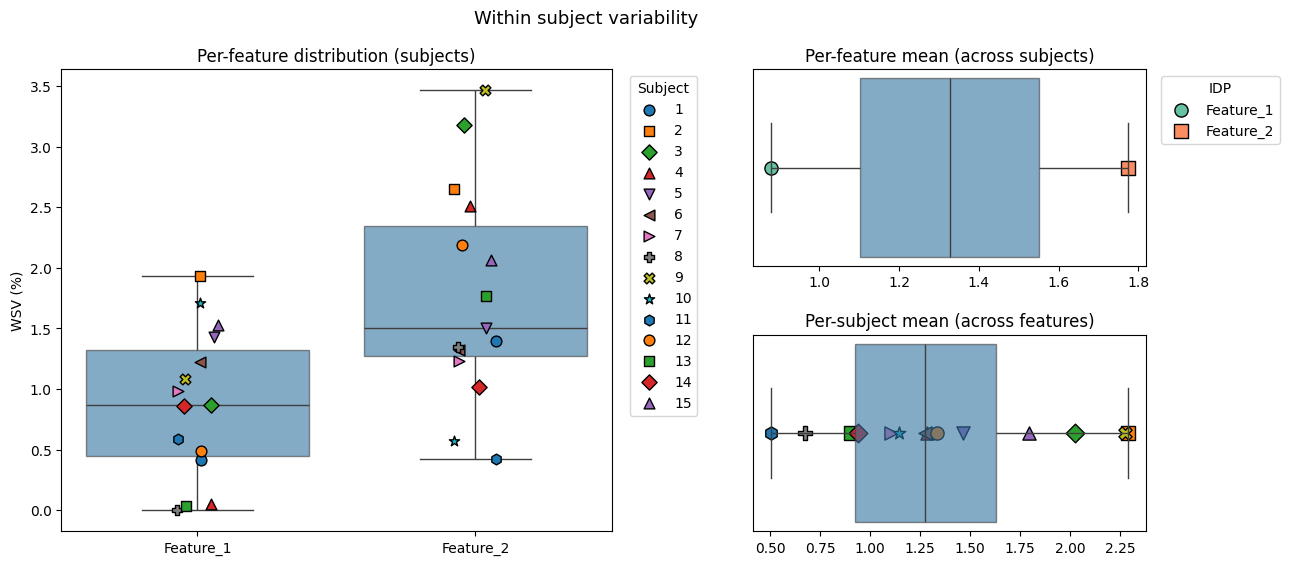

In [3]:
# Run code for calculating within-subject variability
from block2_utils.HarmonisationEvaluation_functions import WithinSubjVar_long
from block2_utils.HarmonisationEvaluation_plots import plot_WithinSubjVar

# df has columns: Subject, Timepoint, Site, features

features = [f"Feature_{i}" for i in range(1, n_features + 1)]

idp_matrix = df[features].to_numpy()
subjects = df["Subject"].to_list()
timepoints = df["Timepoint"].to_list()

# Get within subject variability
result = WithinSubjVar_long(
    idp_matrix=idp_matrix,
    subjects=subjects,
    timepoints=timepoints,
    idp_names=features,
)

# Plot within subject variability
plot_WithinSubjVar(
    result,
    subject_col="subject",
    limit_subjects=n_subjects,
    limit_idps_for_legend=n_features,
)

### Interpretation of Results

The output shows the within-subject variability (%) for each subject. What these plots are showing you -

- *Per-feature distribution*: For each feature (x-axis) and subject (see legend) we plot within-subject variability (%).
- *Per-feature mean*: For each feature (legend), we plot average WSV (%) across subjects.
- *Per-subject mean*: For each subject (legend), we plot average WSV (%) across features.

Because the simulated data represent repeated scans of the same individuals with no expected biological change, differences mainly reflect:

- scanner/site effects,
- measurement noise,
- technical variability.

Higher variability values indicate poorer agreement across repeated measurements, while lower values indicate better consistency.

In the multi-timepoint example, the metric is computed using the coefficient of variation (CoV), which summarizes variability across all repeated scans for each subject.

For harmonisation evaluation:

- High within-subject variability before harmonisation suggests strong scanner/site effects.
- Reduced variability after harmonisation indicates improved consistency across scanners/sites.

---

### Exercise: Extend the simulated data to multiple timepoints

Modify the simulated dataset by increasing number of subjects, timepoints, features etc. and run the code again.

1. Simulate a dataset with:
   - multiple subjects,
   - multiple timepoints,
   - multiple brain regions/features.

2. Run `WithinSubjVar_long()` using the simulated data.

3. Visualize the results using `plot_WithinSubjVar()`.

4. Inspect:
   - within-subject variability values per feature,
   - within-subject variability values per subject/datapoint,
   - differences across features.

#### *Questions*
- Which features pairs show the highest variability?
- Which subjects show the lowest consistency?
- What happens to the within subject variability if scanner/site effects become larger?


#### Within-subject variability analysis from exercise 
 
The within-subject variability analysis shows that the simulated features exhibit different levels of longitudinal stability across repeated measurements.

Overall:

* `Feature_1` showed the lowest variability across subjects (typically ~2–5%)
* `Feature_3` also demonstrated relatively low variability (~4–8%)
* `Feature_4` and `Feature_5` showed moderate variability (~11–15%)
* `Feature_2` consistently showed the highest within-subject variability (~15–20%)

These results suggest that some simulated features are substantially more stable across longitudinal acquisitions, whereas others are more sensitive to scanner/site effects and measurement noise.

The elevated variability observed for `Feature_2` may reflect stronger simulated batch effects or increased noise contributions relative to the other features.


(120, 8)
   Subject Timepoint    Site  Feature_1  Feature_2  Feature_3  Feature_4  \
0        1       TP0  Site_A     3923.1     3049.4     5161.3     5919.5   
1        1       TP1  Site_B     4061.8     4233.0     4357.1     4909.0   
2        1       TP2  Site_C     3769.6     3721.2     4604.3     4801.1   
3        1       TP3  Site_D     3993.2     4732.9     4565.7     5963.7   
4        2       TP0  Site_A     3888.8     3030.4     5272.0     5947.2   

   Feature_5  
0     5222.2  
1     4411.4  
2     5236.8  
3     4044.0  
4     5211.4  
    subject  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0         1   3.177586  18.302832   7.357165  11.654049  12.636952
1         2   2.568923  17.013698   6.762284  11.494846  10.701130
2         3   3.410610  19.577738   6.276240  11.775657  11.331908
3         4   2.903497  18.903159   6.263989  15.858414  12.407633
4         5   2.791192  19.940948   2.745046  13.659523  13.870140
5         6   3.163239  16.962862   5.1981

/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axA.set_xticklabels(
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.95])


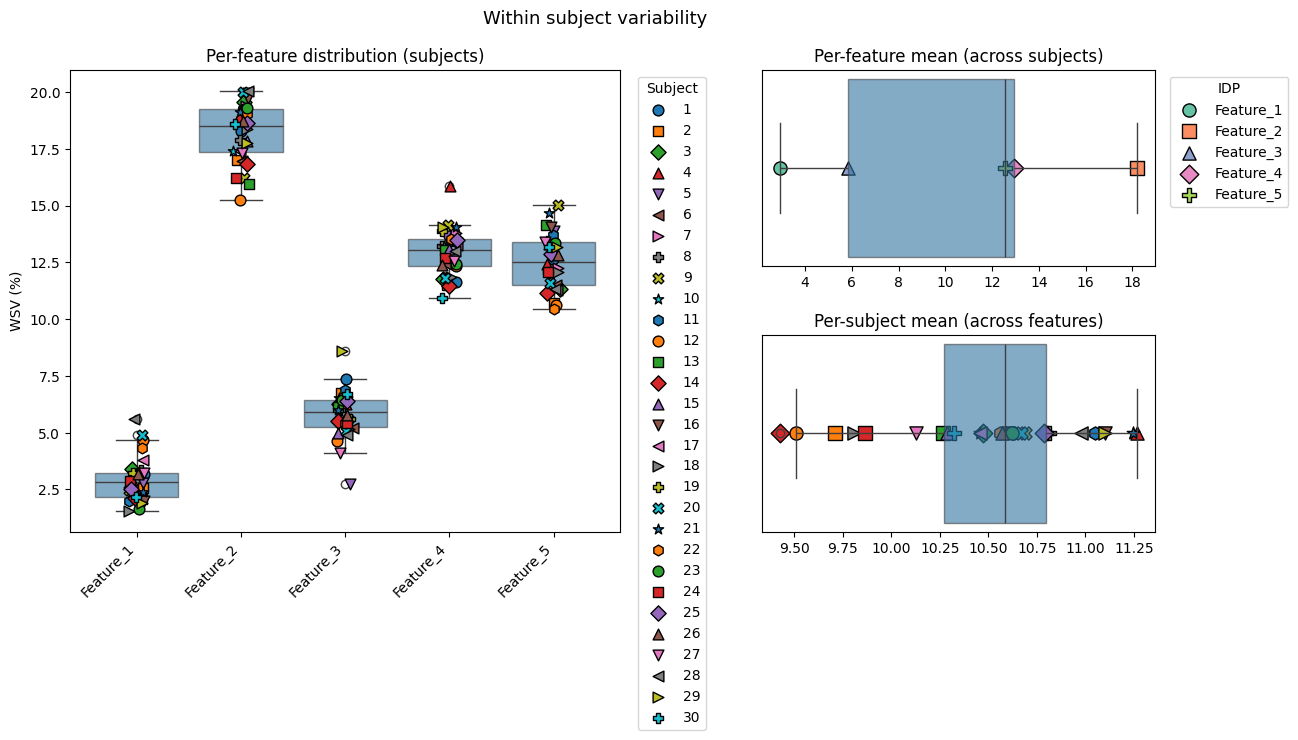

In [5]:
from block2_utils.HarmonisationEvaluation_functions import simulate_harmonisation_data
from block2_utils.HarmonisationEvaluation_functions import WithinSubjVar_long
from block2_utils.HarmonisationEvaluation_plots import plot_WithinSubjVar

# Let's simulate 30 subjects, acquired at 4 timepoints and has 5 features
n_subjects=30
n_timepoints=4 
n_features=5
seed=1
subject_mean=4000
subject_sd=80
noise_sd=80
scale_value=500

df = simulate_harmonisation_data(
    n_subjects=n_subjects, 
    n_timepoints=n_timepoints, 
    n_features=n_features, 
    seed=seed,
    subject_mean=subject_mean, 
    subject_sd=subject_sd, 
    noise_sd=noise_sd,
    scale_value=scale_value
)
print(df.shape)
print(df.head())

# Run code for calculating within-subject variability

# df has columns: Subject, Timepoint, Site, BrainVolume
features = [f"Feature_{i}" for i in range(1, n_features + 1)]
idp_matrix = df[features].to_numpy()
subjects = df["Subject"].to_list()
timepoints = df["Timepoint"].to_list()

# Get within subject variability
result = WithinSubjVar_long(
    idp_matrix=idp_matrix,
    subjects=subjects,
    timepoints=timepoints,
    idp_names=features,
)
print(result)

# Plot within subject variability
plot_WithinSubjVar(
    result,
    subject_col="subject",
    limit_subjects=n_subjects,
    limit_idps_for_legend=n_features,
)

---

## 2. Subject Order Consistency

This function evaluates how consistently subjects retain their relative ordering across timepoints/scanners.

For each IDP, the function computes the **Spearman correlation** between measurements from two timepoints:

- high correlation → subjects maintain a similar ranking across scans
- low correlation → subject ordering changes more across scans

A permutation test is used to compare the observed correlation against correlations expected by chance.

- significant p-values indicate that the observed subject ordering is unlikely to occur randomly
- non-significant p-values suggest weaker or unstable ordering consistency

For harmonisation evaluation, strong and significant subject order consistency suggests that biological differences between subjects are preserved across scanners/timepoints.

(30, 5)
   Subject Timepoint    Site  Feature_1  Feature_2
0        1       TP0  Site_A     2047.4     2872.1
1        1       TP1  Site_B     2038.9     2832.2
2        2       TP0  Site_A     1915.1     2961.4
3        2       TP1  Site_B     1878.5     2883.9
4        3       TP0  Site_A     1873.6     2923.9
  TimeA TimeB        IDP  nPairs  SpearmanRho  NullMeanRho    pValue
0   TP0   TP1  Feature_1      15     0.925000     0.053964  0.009901
1   TP0   TP1  Feature_2      15     0.871429    -0.025714  0.009901


/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:382: RuntimeWarning: Mean of empty slice
  combined_rho_matrix = np.nanmean(stacked, axis=0)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:466: RuntimeWarning: Mean of empty slice
  mean_rho_matrix = np.nanmean(stacked, axis=0)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:608: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.96])


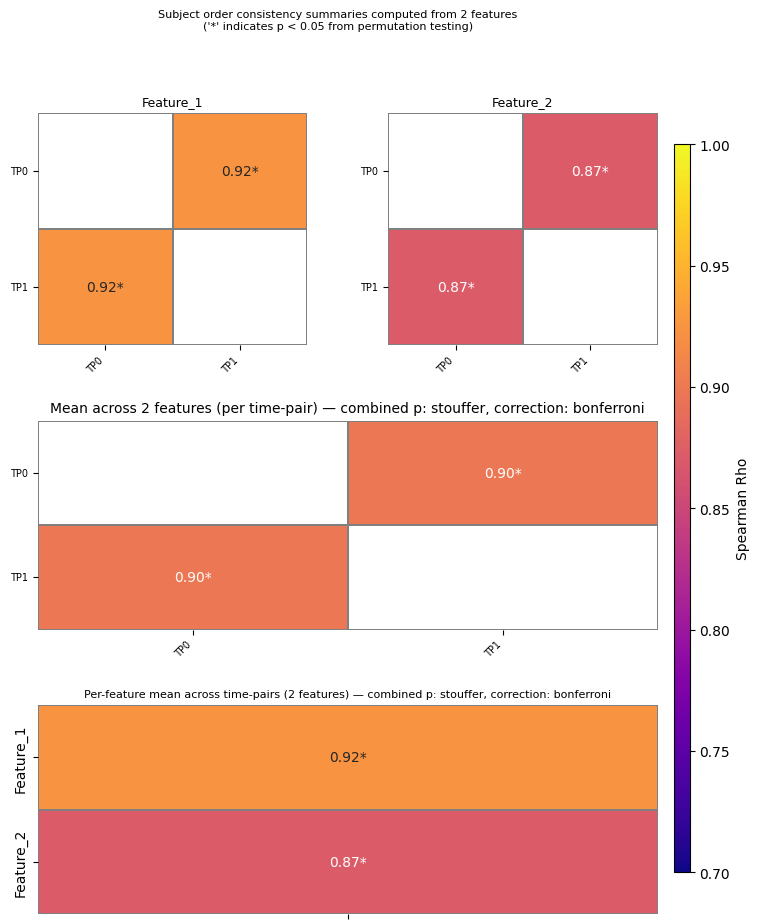

In [8]:
from block2_utils.HarmonisationEvaluation_functions import simulate_harmonisation_data
from block2_utils.HarmonisationEvaluation_functions import SubjectOrder_long
from block2_utils.HarmonisationEvaluation_plots import plot_SubjectOrder

from block2_utils.HarmonisationEvaluation_functions import simulate_harmonisation_data

# Let's simulate 15 subjects, acquired at 2 timepoints and has 2 features
n_subjects=15
n_timepoints=2 
n_features=2
seed=1
subject_mean=2000
subject_sd=80
noise_sd=20
scale_value=100

df = simulate_harmonisation_data(
    n_subjects=n_subjects, 
    n_timepoints=n_timepoints, 
    n_features=n_features, 
    seed=seed,
    subject_mean=subject_mean, 
    subject_sd=subject_sd, 
    noise_sd=noise_sd,
    scale_value=scale_value
)
print(df.shape)
print(df.head())

# df has columns: Subject, Timepoint, Site, Features
features = [f"Feature_{i}" for i in range(1, n_features + 1)]
idp_matrix = df[features].to_numpy()
subjects = df["Subject"].to_list()
timepoints = df["Timepoint"].to_list()

subjorder = SubjectOrder_long(
    idp_matrix=idp_matrix,
    subjects=subjects,
    timepoints=timepoints,
    idp_names=features,
    nPerm=100
)
print(subjorder)

plot_SubjectOrder(subjorder, p_correction="bonferroni", cmap="plasma", cmap_limits=[0.7,1])

## Exercise: Subject Order Consistency Across Timepoints

In this exercise, we evaluate whether subjects retain a similar relative ordering across repeated scans.

### Tasks

1. Simulate a dataset with:
   - multiple subjects,
   - multiple timepoints,
   - multiple brain regions/features.

2. Run `SubjectOrder_long()` using the simulated data.

3. Visualize the results using `plot_SubjectOrder()`.

4. Inspect:
   - Spearman correlation values,
   - permutation-test p-values,
   - differences across regions and timepoint pairs.

---

### Overall Interpretation

- High Spearman correlations indicate that subjects maintain a similar ranking across scans.
- Significant permutation-test p-values indicate that the observed consistency is stronger than expected by chance.
- Strong subject order consistency after harmonisation suggests that biological differences between subjects are preserved while scanner-related effects are reduced.

---

### Questions

- Which timepoint pairs show the strongest consistency?
- Which regions show weaker consistency?
- What happens to the correlations if scanner/site effects become larger?
- Why is preserving subject ordering important in harmonisation?


#### Interpretation of the Subject-Order Consistency Results from exercise 

The Spearman correlation analysis demonstrates varying levels of subject-order consistency across longitudinal timepoint pairs and simulated features.

Overall, the strongest consistency was observed for comparisons involving later timepoints, particularly:

* **TP1–TP3**
* **TP2–TP3**
* **TP1–TP2**

For example:

* `Feature_1` showed very high correlations for:

  * TP1–TP3 (`ρ = 0.716`, `p = 0.0099`)
  * TP2–TP3 (`ρ = 0.690`, `p = 0.0099`)
  * TP1–TP2 (`ρ = 0.667`, `p = 0.0099`)

Similarly, `Feature_3` and `Feature_4` demonstrated moderate-to-strong consistency across several timepoint pairs, with many statistically significant correlations.

In contrast, lower subject-order consistency was observed for:

* `Feature_2`
* `Feature_5`

particularly for:

* TP0–TP1
* TP1–TP2
* TP2–TP3

Examples include:

* `Feature_5`, TP2–TP3 (`ρ = 0.051`, `p = 0.772`)
* `Feature_2`, TP0–TP1 (`ρ = 0.083`, `p = 0.703`)

These low correlations suggest weaker preservation of subject ranking across these timepoint pairs, potentially reflecting stronger simulated site effects, measurement noise, or reduced feature stability.

Overall, the results illustrate that some features remain relatively stable across longitudinal acquisitions despite scanner/site differences, whereas others are substantially more sensitive to simulated batch effects and noise.


(120, 8)
   Subject Timepoint    Site  Feature_1  Feature_2  Feature_3  Feature_4  \
0        1       TP0  Site_A     3923.1     3049.4     5161.3     5919.5   
1        1       TP1  Site_B     4061.8     4233.0     4357.1     4909.0   
2        1       TP2  Site_C     3769.6     3721.2     4604.3     4801.1   
3        1       TP3  Site_D     3993.2     4732.9     4565.7     5963.7   
4        2       TP0  Site_A     3888.8     3030.4     5272.0     5947.2   

   Feature_5  
0     5222.2  
1     4411.4  
2     5236.8  
3     4044.0  
4     5211.4  
   TimeA TimeB        IDP  nPairs  SpearmanRho  NullMeanRho    pValue
0    TP0   TP1  Feature_1      30     0.342825    -0.039889  0.089109
1    TP0   TP1  Feature_2      30     0.082768    -0.024183  0.702970
2    TP0   TP1  Feature_3      30     0.431115    -0.036537  0.029703
3    TP0   TP1  Feature_4      30     0.471858     0.020418  0.019802
4    TP0   TP1  Feature_5      30     0.344160    -0.006905  0.079208
5    TP0   TP2  Feature_

/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:382: RuntimeWarning: Mean of empty slice
  combined_rho_matrix = np.nanmean(stacked, axis=0)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:466: RuntimeWarning: Mean of empty slice
  mean_rho_matrix = np.nanmean(stacked, axis=0)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block02/block2_utils/HarmonisationEvaluation_plots.py:608: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.96])


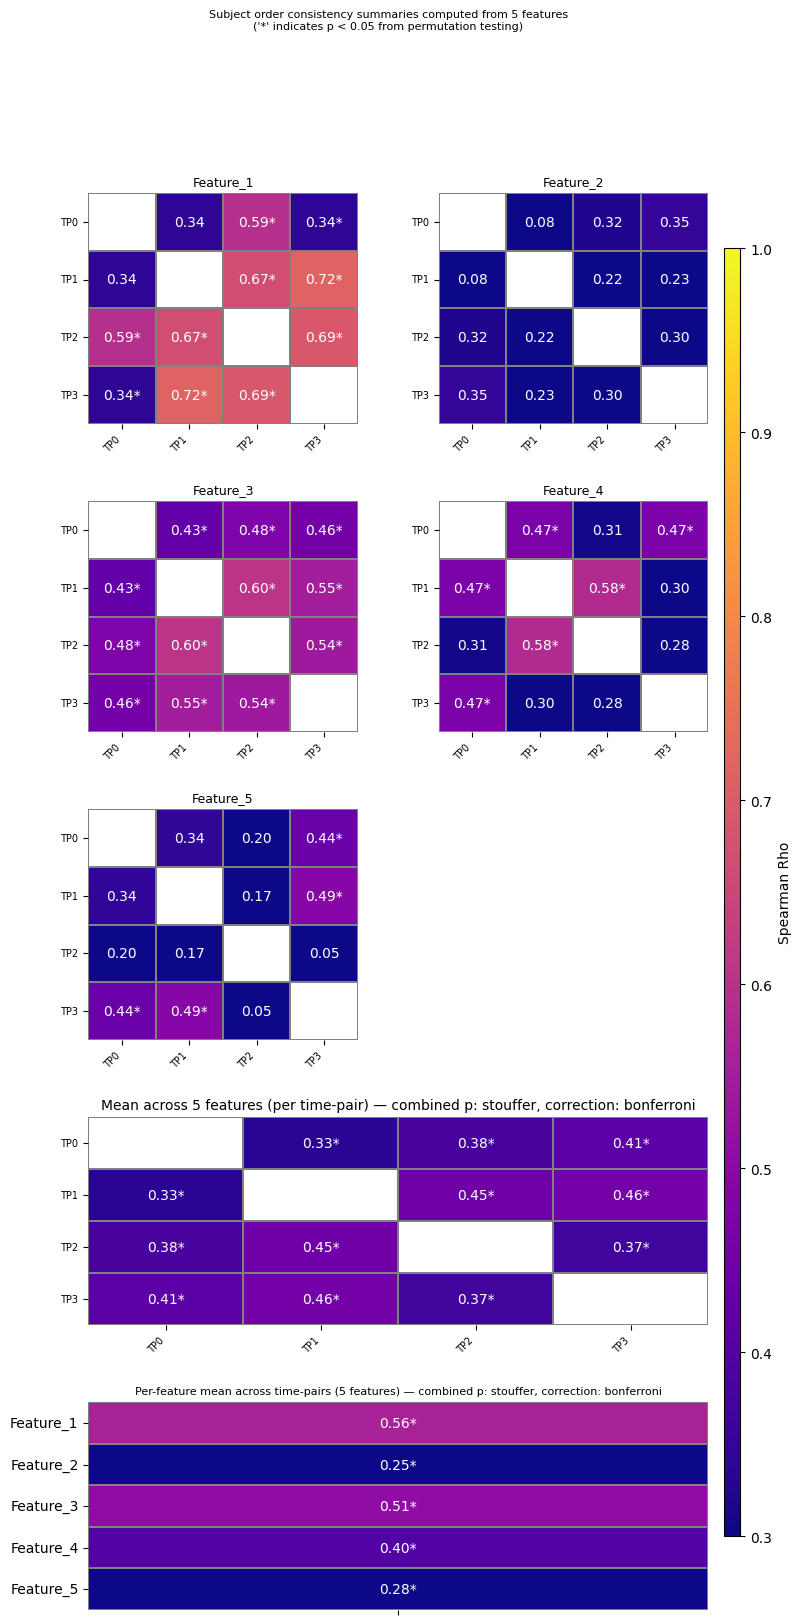

In [10]:
from block2_utils.HarmonisationEvaluation_functions import simulate_harmonisation_data
from block2_utils.HarmonisationEvaluation_functions import SubjectOrder_long
from block2_utils.HarmonisationEvaluation_plots import plot_SubjectOrder

# Let's simulate 30 subjects, acquired at 4 timepoints and has 5 features
n_subjects=30
n_timepoints=4 
n_features=5
seed=1
subject_mean=4000
subject_sd=80
noise_sd=80
scale_value=500

df = simulate_harmonisation_data(
    n_subjects=n_subjects, 
    n_timepoints=n_timepoints, 
    n_features=n_features, 
    seed=seed,
    subject_mean=subject_mean, 
    subject_sd=subject_sd, 
    noise_sd=noise_sd,
    scale_value=scale_value
)
print(df.shape)
print(df.head())

# df has columns: Subject, Timepoint, Site, Features
features = [f"Feature_{i}" for i in range(1, n_features + 1)]
idp_matrix = df[features].to_numpy()
subjects = df["Subject"].to_list()
timepoints = df["Timepoint"].to_list()

subjorder = SubjectOrder_long(
    idp_matrix=idp_matrix,
    subjects=subjects,
    timepoints=timepoints,
    idp_names=features,
    nPerm=100
)
print(subjorder)

plot_SubjectOrder(subjorder, p_correction="bonferroni", cmap="plasma", cmap_limits=[0.3,1])

---

## 3. Additive Batch Effect

This test asks whether the scanner/site (`batch`) adds a systematic shift to the measurements after accounting for covariates and subject-level random effects.

A simplified model is:

$$
y_{ij} = \beta_0 + \beta^T X_{ij} + \alpha_{b(i)} + u_i + \varepsilon_{ij}
$$

where:

- $y_{ij}$ = measurement for subject $i$ at observation $j$
- $X_{ij}$ = fixed effects / covariates
- $\alpha_{b(i)}$ = additive batch/site effect
- $u_i$ = subject-specific random effect
- $\varepsilon_{ij}$ = residual error

The function compares:

$$
\text{Full model: } y \sim X + \text{batch} + (1 | \text{subject})
$$

vs.

$$
\text{Reduced model: } y \sim X + (1 | \text{subject})
$$

A significant p-value suggests that the batch/site term explains additional variation, indicating an **additive batch effect**.

For harmonisation, this is the kind of shift that methods like ComBat are designed to remove.

---

## 4. Multiplicative Batch Effect

This test asks whether the variance differs across batches/sites after accounting for covariates and subject-level random effects.

A simplified model is:

$$
y_{ij} = \beta_0 + \beta^T X_{ij} + \alpha_{b(i)} + u_i + \varepsilon_{ij}
$$

The key difference is that the residual spread is compared across batch groups.

After fitting the mixed model, the residuals are tested with a variance test:

$$
H_0: \sigma^2_1 = \sigma^2_2 = \cdots = \sigma^2_K
$$

vs.

$$
H_1: \text{at least one batch has different variance}
$$

The function uses the **Fligner-Killeen test** on model residuals grouped by batch.

A significant p-value suggests a **multiplicative batch effect**, meaning one site/scanner has more or less variability than another.

For harmonisation, this corresponds to a scale/variance difference rather than a mean shift.

## Interpretation

- **Additive effect significant**: batches differ in mean level.
- **Multiplicative effect significant**: batches differ in variance.
- **Both significant**: scanner/site influences both location and spread.

In a longitudinal harmonisation setting, successful correction should reduce both effects while preserving subject-level structure and true biological change.

---

## Simulating longitudinal data with additive and multiplicative batch effects

This simulation generates synthetic longitudinal imaging data with:

* subject-specific biological variability
* longitudinal change over time
* age effects
* site/scanner batch effects
* random measurement noise

Unlike the previous simulation, site and timepoint are **not perfectly confounded**. Each subject can be scanned at different sites across timepoints:

```python
subject_sites = np.random.choice(sites, size=n_timepoints, replace=True)
```

This creates a another realistic harmonisation scenario.

The simulated observed value is approximately:

```text
Observed value
=
True biological signal
+ Additive site effect
+ Measurement noise
```

where:

* `additive_shift` introduces site-specific offsets
* `multiplicative_scale` changes the amount of site-specific noise
* `slope_sd` controls longitudinal subject trajectories
* `noise_sd` controls random measurement variability

This simulation is useful for studying how additive and multiplicative scanner/site effects influence longitudinal analyses and harmonisation methods.


   Subject Timepoint    Site   Age  Feature_1  Feature_2  Feature_3  Feature_4
0        1       TP0  Site_B  78.0     2180.5      889.5     2362.7     2381.3
1        1       TP1  Site_A  78.0     1553.1     1432.5     2487.1     2300.5
2        1       TP2  Site_A  78.0     1533.2     1459.7     2497.8     2438.0
3        2       TP0  Site_A  60.1     1660.3     1607.4     2150.7     2492.0
4        2       TP1  Site_B  60.1     2284.2     2084.6     1978.2     2424.2
5        2       TP2  Site_A  60.1     1700.5     1658.8     2159.9     2546.7
6        3       TP0  Site_A  60.8     1634.4     1476.3     2191.8     2337.9
7        3       TP1  Site_A  60.8     1626.8     1512.9     2169.2     2451.1
8        3       TP2  Site_A  60.8     1634.4     1512.3     2220.3     2416.5
9        4       TP0  Site_A  56.4     1629.5     1742.7     2199.9     2451.6


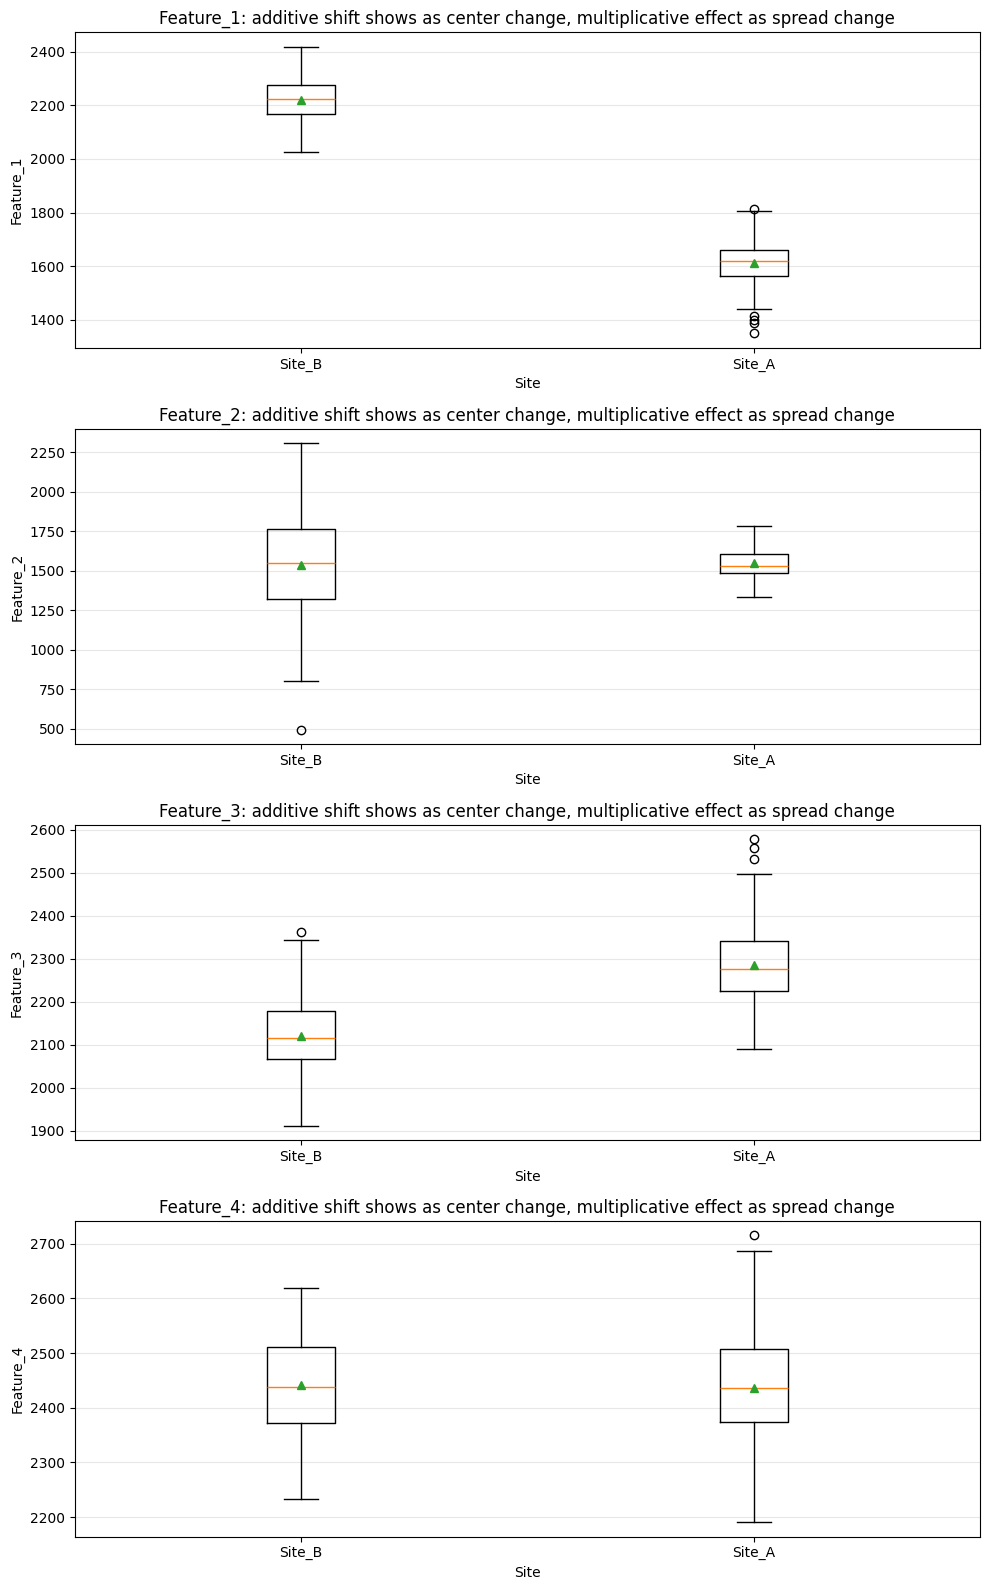

In [2]:
from block2_utils.HarmonisationEvaluation_functions import simulate_longitudinal_batch_data_mixed
from block2_utils.HarmonisationEvaluation_plots import plot_additive_multiplicative_effects

# Let's simulate some data: 100 subjects, 3 timepoints, 2 sites, features from 4 brain regions
n_subjects=100
n_timepoints=3
n_sites=2
n_features=4
additive_shift = {"Site_B": {"Feature_1": 600, "Feature_3": -150}}
multiplicative_scale = {"Site_B": {"Feature_2": 15.0}, "Site_A": {"Feature_4": 2.7}}

df = simulate_longitudinal_batch_data_mixed(
    n_subjects=n_subjects,
    n_timepoints=n_timepoints,
    n_sites=n_sites,
    n_features=n_features,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
    seed=1,
)

print(df.head(10))
feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

# Let's visualise additive and multiplicative effects
plot_additive_multiplicative_effects(df, feature_cols=feature_cols, batch_col="Site")


In [ ]:
from block2_utils.HarmonisationEvaluation_functions import AdditiveEffect_long
from block2_utils.HarmonisationEvaluation_functions import MultiplicativeEffect_long
import warnings

feature_cols = [f"Feature_{i}" for i in range(1, n_features + 1)]

# let's estimate additive and multiplicative batch effects
additive_results, model_defs_add = AdditiveEffect_long(
    data=df,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(additive_results)

multiplicative_results, model_defs_mul = MultiplicativeEffect_long(
    data=df,
    idp_names=feature_cols,
    idvar="Subject",
    batchvar="Site",
    timevar="Timepoint",
    fix_eff=["Age"],
    ran_eff=["Subject"],
    do_zscore=True,
    verbose=False,
)
print(multiplicative_results)


/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/

     Feature      TestStat  df   p-value method
0  Feature_1  42809.429774   1  0.000000   Wald
1  Feature_3   3243.301501   1  0.000000   Wald
2  Feature_4      0.140928   1  0.707360   Wald
3  Feature_2      0.072801   1  0.787301   Wald


/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


     Feature      ChiSq  DF       p-value   method
0  Feature_2  93.614470   1  3.833746e-22  Fligner
1  Feature_4  28.095495   1  1.154743e-07  Fligner
2  Feature_3   0.018010   1  8.932425e-01  Fligner
3  Feature_1   0.013899   1  9.061513e-01  Fligner


### Interpreting results from additive and multiplicative effect analysis

The additive batch effect analysis identified significant site-related mean shifts for:

* `Feature_1`
* `Feature_3`

both showing extremely small p-values (`p < 0.001`), indicating strong additive scanner/site effects.

In contrast:

* `Feature_2`
* `Feature_4`

did not show significant additive batch effects, suggesting that their mean feature values were relatively consistent across sites.

The multiplicative batch effect analysis (Fligner test) demonstrated significant differences in variance across sites for:

* `Feature_2`
* `Feature_4`

indicating the presence of multiplicative batch effects or site-specific changes in measurement variability.

Conversely:

* `Feature_1`
* `Feature_3`

did not exhibit significant multiplicative effects, suggesting more stable variance across sites.

Overall, these results demonstrate that different simulated features can be affected by different types of scanner/site bias:

* some primarily through shifts in mean values (additive effects)
* others through changes in variability (multiplicative effects)


---

## Further Reading

For additional methodological details, implementation examples, and extended discussions of harmonisation evaluation approaches, see:

- **Paper:**  
  [Harmonising Structural Brain MRI from Multiple Sites with Limited Sample Sizes](https://doi.org/10.64898/2026.04.21.26351106)

- **Tool/Repository:**  
  [More evaluation metrics](https://jake-turnbull.github.io/HarmonisationDiagnostics/)